In [6]:
print("notebook works")


notebook works


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nicer default look for charts
sns.set_theme(style="whitegrid")

# Labels are stored as integers; keep a name map for readable charts
LABEL_NAMES = {0: "negative", 1: "neutral", 2: "positive"}

df = pd.read_csv("../data/raw/financial_phrasebank.csv")
df["label_name"] = df["label"].map(LABEL_NAMES)

df.head()

,sentence,label,label_name
0,"According to Gran , the company has no plans t...",1,neutral
1,Technopolis plans to develop in stages an area...,1,neutral
2,The international electronic industry company ...,0,negative
3,With the new production plant the company woul...,2,positive
4,According to the company 's updated strategy f...,2,positive


In [8]:
print("Shape (rows, columns):", df.shape)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate sentences:", df["sentence"].duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape (rows, columns): (4836, 3)

Missing values per column:
sentence      0
label         0
label_name    0
dtype: int64

Duplicate rows: 0
Duplicate sentences: 0

Data types:
sentence        str
label         int64
label_name      str
dtype: object


In [5]:
# Show sentences that appear more than once
dupe_mask = df["sentence"].duplicated(keep=False)   # keep=False flags ALL copies
dupes = df[dupe_mask].sort_values("sentence")
print(f"Rows involved in duplication: {len(dupes)}\n")
dupes

Rows involved in duplication: 16



,sentence,label,label_name
2395,Ahlstrom 's share is quoted on the NASDAQ OMX ...,1,neutral
2396,Ahlstrom 's share is quoted on the NASDAQ OMX ...,1,neutral
3093,Proha Plc ( Euronext :7327 ) announced today (...,1,neutral
3094,Proha Plc ( Euronext :7327 ) announced today (...,1,neutral
2566,SSH Communications Security Corporation is hea...,1,neutral
2567,SSH Communications Security Corporation is hea...,1,neutral
78,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,1,neutral
79,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...,2,positive
788,The Group 's business is balanced by its broad...,2,positive
789,The Group 's business is balanced by its broad...,1,neutral


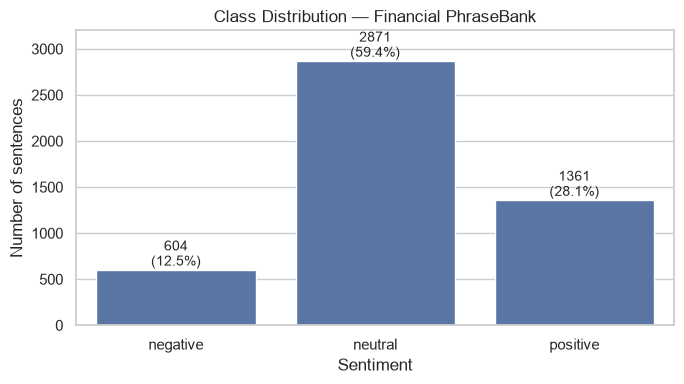

In [9]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x="label_name", order=["negative", "neutral", "positive"])

# Add count + percentage labels on top of each bar
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(f"{count}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.title("Class Distribution — Financial PhraseBank")
plt.xlabel("Sentiment")
plt.ylabel("Number of sentences")
plt.ylim(0, 3200)  # headroom so labels aren't clipped
plt.tight_layout()
plt.show()

count    4836.000000
mean       23.086849
std         9.937150
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: word_count, dtype: float64

95th percentile: 42.0
99th percentile: 50.0
Max: 81


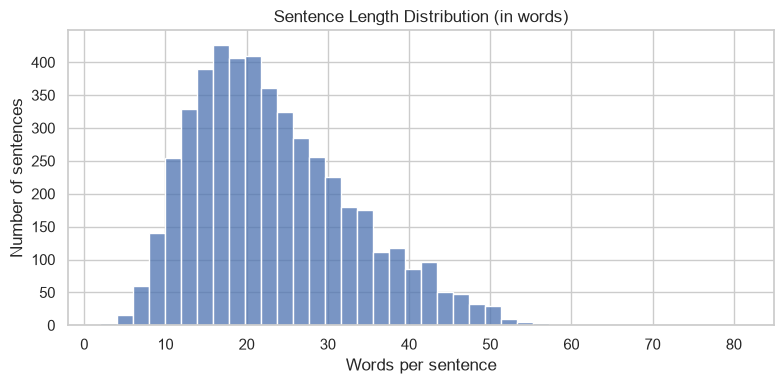

In [10]:
# Measure length in WORDS (a quick, intuitive proxy)
df["word_count"] = df["sentence"].str.split().str.len()

print(df["word_count"].describe())
print("\n95th percentile:", df["word_count"].quantile(0.95))
print("99th percentile:", df["word_count"].quantile(0.99))
print("Max:", df["word_count"].max())

plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=40)
plt.title("Sentence Length Distribution (in words)")
plt.xlabel("Words per sentence")
plt.ylabel("Number of sentences")
plt.tight_layout()
plt.show()

In [11]:
from transformers import AutoTokenizer

# The exact tokenizer FinBERT uses
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")

# Tokenize every sentence and count actual tokens (includes [CLS]/[SEP])
token_counts = df["sentence"].apply(lambda s: len(tokenizer.encode(s)))

print(token_counts.describe())
print("\n95th percentile:", token_counts.quantile(0.95))
print("99th percentile:", token_counts.quantile(0.99))
print("Max tokens:", token_counts.max())

# How many sentences would exceed a max_length of 128?
over_128 = (token_counts > 128).sum()
print(f"\nSentences longer than 128 tokens: {over_128} ({100*over_128/len(df):.2f}%)")

c:\Users\ASUS\Desktop\finbert-sentiment\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


count    4836.000000
mean       30.588296
std        13.582147
min         4.000000
25%        21.000000
50%        28.000000
75%        38.000000
max       150.000000
Name: sentence, dtype: float64

95th percentile: 57.0
99th percentile: 68.0
Max tokens: 150

Sentences longer than 128 tokens: 1 (0.02%)


In [ ]:
## EDA Summary — Key Insights

**Dataset:** Financial PhraseBank, 4,836 sentences (after removing 10 duplicate/conflicting rows).

**1. Class imbalance (important):**
- Neutral: 59.4% (2,871)
- Positive: 28.1% (1,361)
- Negative: 12.5% (604)
- → Accuracy alone is misleading; evaluate with **macro-F1** and per-class metrics.
- → Use a **stratified** train/val/test split to preserve these proportions.

**2. Data quality:** No missing values. Removed 8 duplicate sentences, including 2 with conflicting labels (dropped entirely to avoid label noise and train/test leakage).

**3. Sequence length:** Median 28 tokens, 99th percentile 68 tokens, max 150 (FinBERT tokenizer). Only 1 sentence exceeds 128 tokens.
- → Set **max_length = 128**: covers 99.98% of data with no meaningful truncation, hardware-efficient.